# Spatially variable genes

**Block 3** | A spatially variable gene (SVG) is not one thing: autocorrelation/smoothness,
differential expression between domains, and characteristic length scale are three
different questions that happen to share a name. This notebook stays with Moran's I
(the convenient, AnnData-native option) and spends most of its time on what makes an SVG
list misleading rather than on finding more genes.

Imputation (predicting genes that were never measured) is not covered hands-on in this
notebook this year. Nothing below imputes anything; the held-out-gene approach from earlier
plans is out of scope for this notebook.


## Setup


In [1]:
%matplotlib inline

import pathlib
import sys

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "paths.py").exists())
sys.path.insert(0, str(ROOT))


In [2]:
import logging
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import spatialdata as sd
import spatialdata_plot  # noqa: F401
import squidpy as sq
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import squareform

import paths

warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("ome_zarr").setLevel(logging.WARNING)

sdata = sd.read_zarr(paths.data("xenium_breast_2fov.zarr"))
adata = sdata["table"]
adata.obs["control_fraction"] = (
    adata.obs[["control_probe_counts", "control_codeword_counts", "unassigned_codeword_counts"]].sum(axis=1)
    / adata.obs["total_counts"].clip(lower=1)
)
keep = (
    (adata.obs["total_counts"] >= 10)
    & (adata.obs["nucleus_count"] >= 1)
    & (adata.obs["control_fraction"] <= 0.05)
)
adata = adata[keep].copy()
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.layers["lognorm"] = adata.X.copy()

celltype_file = paths.precomputed("xenium_celltypes.h5ad")
if celltype_file is not None:
    adata.obs["cell_type"] = ad.read_h5ad(celltype_file).obs["cell_type"].reindex(adata.obs_names)
    print(f"cell types loaded from cache: {celltype_file}")
else:
    # Same procedure as notebook 1, section 1, repeated here so this notebook runs
    # standalone from a fresh kernel, matching Day 1's convention.
    print("cell type cache not found, recomputing (see notebook 1 for the full explanation)")
    markers = {
        "epithelial_tumor": ["EPCAM", "KRT8", "KRT7", "CDH1", "ESR1", "PGR", "ERBB2", "GATA3",
                             "FOXA1", "TACSTD2", "MLPH", "ANKRD30A", "AGR3", "S100A14", "CEACAM6", "TPD52"],
        "myoepithelial": ["ACTA2", "MYH11", "MYLK", "KRT14", "KRT5", "OXTR"],
        "t_nk_cell": ["CD3E", "CD3G", "CD247", "CD4", "CD8A", "IL7R", "TRAC", "TCF7", "CTLA4",
                      "FOXP3", "GNLY", "NKG7", "KLRD1", "KLRF1", "KLRC1", "PRF1", "GZMA", "GZMK", "KLRB1", "CCL5"],
        "b_plasma_cell": ["MS4A1", "CD79A", "CD79B", "CD19", "BANK1", "TCL1A", "MZB1", "TNFRSF17", "PRDM1", "SLAMF7"],
        "myeloid": ["CD68", "CD14", "CD163", "LYZ", "C1QA", "C1QC", "ITGAM", "ITGAX", "MRC1",
                    "FCGR3A", "AIF1", "MNDA", "APOC1", "FCER1G"],
        "mast_cell": ["TPSAB1", "CPA3", "CTSG", "KIT"],
        "dendritic_cell": ["CLEC9A", "FCER1A", "LILRA4", "IL3RA", "CLECL1"],
        "endothelial": ["PECAM1", "VWF", "CLEC14A", "EGFL7", "RAMP2", "AQP1", "SOX17", "SOX18",
                         "KDR", "MMRN2", "ESM1", "NOSTRIN", "CD93"],
        "fibroblast_stromal": ["PDGFRA", "PDGFRB", "LUM", "FBLN1", "POSTN", "DPT", "SFRP4",
                                "SFRP1", "MMP2", "CXCL12", "LRRC15", "CCDC80"],
        "adipocyte": ["ADIPOQ", "LPL", "UCP1", "PPARG"],
    }
    scaled = adata.copy()
    sc.pp.scale(scaled, max_value=10)
    sc.pp.pca(scaled, n_comps=50)
    sc.pp.neighbors(scaled)
    sc.tl.leiden(scaled, resolution=1.0, flavor="igraph", n_iterations=2, random_state=0)
    Xs = pd.DataFrame(scaled.X, columns=scaled.var_names, index=scaled.obs_names)
    mean_expr = pd.DataFrame({name: Xs[genes].mean(axis=1) for name, genes in markers.items()})
    mean_expr["leiden"] = scaled.obs["leiden"].values
    cluster_mean = mean_expr.groupby("leiden").mean()
    sorted_vals = np.sort(cluster_mean.values, axis=1)
    margin = sorted_vals[:, -1] - sorted_vals[:, -2]
    top_label = cluster_mean.idxmax(axis=1)
    final_label = top_label.where(margin >= 0.15, other="epithelial_tumor")
    adata.obs["cell_type"] = scaled.obs["leiden"].map(final_label).astype("category")
print(f"{adata.n_obs} cells after QC")


no parent found for <ome_zarr.reader.Label object at 0x7ea49e6e9df0>: None


no parent found for <ome_zarr.reader.Label object at 0x7ea49c32fd40>: None


cell types loaded from cache: /opt/workshop/data/precomputed/xenium_celltypes.h5ad
6906 cells after QC


## 1. The graph, again

Moran's I needs a spatial weight matrix, the same graph used earlier in the course, doing the
same job again: deciding what "nearby" means before anything else can be computed.


In [3]:
svg_by_k = {}
for k in [6, 30]:
    a = adata.copy()
    sq.gr.spatial_neighbors_knn(a, n_neighs=k)
    res = sq.gr.spatial_autocorr(a, mode="moran", genes=a.var_names.tolist(), n_perms=None, show_progress_bar=False, copy=True)
    svg_by_k[k] = res
    print(f"n_neighs={k}, top 5:")
    print(res.sort_values("I", ascending=False).head(5)[["I"]])
    print()

top50_k6 = set(svg_by_k[6].sort_values("I", ascending=False).head(50).index)
top50_k30 = set(svg_by_k[30].sort_values("I", ascending=False).head(50).index)
print(f"top-50 overlap (k=6 vs k=30): {len(top50_k6 & top50_k30)}/50")


INFO     Creating graph using `None` transform and `1` libraries.                                                  


n_neighs=6, top 5:
              I
LUM    0.653805
EPCAM  0.642421
LDHB   0.638253
LYZ    0.631995
SFRP1  0.584985

INFO     Creating graph using `None` transform and `1` libraries.                                                  


n_neighs=30, top 5:
              I
LDHB   0.572615
EPCAM  0.570106
LUM    0.546587
LYZ    0.542346
AQP1   0.502258

top-50 overlap (k=6 vs k=30): 47/50


> **_Question:_** The absolute Moran's I values shrink noticeably from `k=6` to `k=30`
> even though the top-50 gene *identities* barely move. Why would averaging over more
> neighbours systematically pull every I towards zero, regardless of which genes they are?


## 2. Normalisation

Rank the same genes by Moran's I computed on raw counts, log-normalised expression, and
scaled (z-scored) expression. Nothing about the tissue changed between these three columns.


In [4]:
sq.gr.spatial_neighbors_knn(adata, n_neighs=15)

variants = {}
a = adata.copy(); a.X = a.layers["counts"].copy()
variants["raw counts"] = a
a = adata.copy(); a.X = a.layers["lognorm"].copy()
variants["log-normalised"] = a
a = adata.copy(); a.X = a.layers["lognorm"].copy(); sc.pp.scale(a, max_value=10)
variants["scaled"] = a

rankings = {}
for name, a in variants.items():
    sq.gr.spatial_neighbors_knn(a, n_neighs=15)
    res = sq.gr.spatial_autocorr(a, mode="moran", genes=a.var_names.tolist(), n_perms=None, show_progress_bar=False, copy=True)
    rankings[name] = res["I"].rank(ascending=False)

rank_df = pd.DataFrame(rankings)
print(rank_df.corr(method="spearman").round(3))
print()
print("top 10 by raw-count rank, and where each lands under the other two normalisations:")
print(rank_df.sort_values("raw counts").head(10))


INFO     Creating graph using `None` transform and `1` libraries.                                                  


INFO     Creating graph using `None` transform and `1` libraries.                                                  


/opt/workshop/physalia/.pixi/envs/default/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


INFO     Creating graph using `None` transform and `1` libraries.                                                  


INFO     Creating graph using `None` transform and `1` libraries.                                                  


                raw counts  log-normalised  scaled
raw counts           1.000           0.977   0.979
log-normalised       0.977           1.000   0.997
scaled               0.979           0.997   1.000

top 10 by raw-count rank, and where each lands under the other two normalisations:
        raw counts  log-normalised  scaled
LYZ            1.0             4.0     4.0
LUM            2.0             3.0     3.0
FCER1G         3.0             7.0     7.0
EPCAM          4.0             2.0     2.0
LDHB           5.0             1.0     1.0
CD68           6.0            11.0    11.0
TUBB2B         7.0            15.0    15.0
CXCL12         8.0             8.0     8.0
HMGA1          9.0            10.0    10.0
SFRP4         10.0             9.0     9.0


Spearman correlation stays high (>0.97) across all three, but individual genes move several
places: a gene that leads under raw counts is not guaranteed to lead under log-normalisation.
The overall shape of "what's spatially structured" survives; the exact top-10 you would
report in a methods section does not.


## 3. Condition on cell type

This is the confounder to make concrete: a marker gene for a cell type that itself sits in
one region of the tissue is *trivially* spatially variable, with nothing to do with
spatial regulation of that gene. Recompute Moran's I using only the most abundant cell type
(`epithelial_tumor`), same graph logic, restricted to cells that share a type.


In [5]:
res_global = sq.gr.spatial_autocorr(adata, mode="moran", genes=adata.var_names.tolist(), n_perms=None, show_progress_bar=False, copy=True)
top20_global = res_global.sort_values("I", ascending=False).head(20).index.tolist()

sub = adata[adata.obs["cell_type"] == "epithelial_tumor"].copy()
sq.gr.spatial_neighbors_knn(sub, n_neighs=15)
res_within = sq.gr.spatial_autocorr(sub, mode="moran", genes=top20_global, n_perms=None, show_progress_bar=False, copy=True)

comparison = pd.DataFrame({"I_global": res_global.loc[top20_global, "I"], "I_within_epithelial_tumor": res_within["I"]})
comparison["survives (I > 0.1)"] = comparison["I_within_epithelial_tumor"] > 0.1
print(comparison.round(3))
print()
n_survive = comparison["survives (I > 0.1)"].sum()
print(f"{n_survive}/20 top global SVGs keep I > 0.1 once you condition on cell type")


INFO     Creating graph using `None` transform and `1` libraries.                                                  


          I_global  I_within_epithelial_tumor  survives (I > 0.1)
ACTA2        0.410                      0.071               False
AIF1         0.316                      0.036               False
APOC1        0.359                      0.073               False
AQP1         0.532                      0.157                True
CCDC80       0.356                      0.042               False
CD4          0.352                      0.034               False
CD68         0.455                      0.101                True
CXCL12       0.465                      0.042               False
EPCAM        0.603                      0.101                True
FCER1G       0.487                      0.132                True
HMGA1        0.455                      0.072               False
LDHB         0.604                      0.056               False
LUM          0.594                      0.114                True
LYZ          0.584                      0.120                True
MMP2      

Just under half survive; the rest collapse from I in the 0.3-0.6 range down to 0.03-0.1,
i.e. most of what looked like spatial structure was actually "this gene marks a cell type,
and that cell type has a location," not within-type spatial regulation. **Spatially
variable is not the same claim as spatially regulated.**

> **_Question:_** `TUBB2B` and `SERPINA3` are two of the genes that *do* survive
> conditioning. What would you check next before calling either one "spatially regulated
> within epithelial cells"?


## 4. HVG vs SVG: two different questions

Highly variable genes are ranked by dispersion across all cells, ignoring position entirely.
SVGs are ranked by spatial autocorrelation, ignoring how variable they are overall. A gene
can be either, both, or neither.


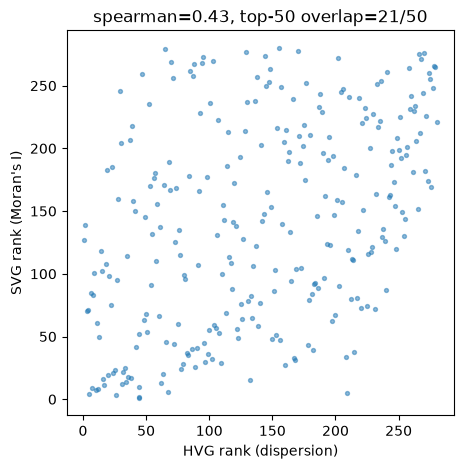

In [6]:
sc.pp.highly_variable_genes(adata, n_top_genes=100)
hvg_rank = adata.var["dispersions_norm"].rank(ascending=False)
svg_rank = res_global["I"].rank(ascending=False)

rank_df = pd.DataFrame({"hvg_rank": hvg_rank, "svg_rank": svg_rank.reindex(hvg_rank.index)}).dropna()
spearman = rank_df.corr(method="spearman").iloc[0, 1]
top50_hvg = set(rank_df.sort_values("hvg_rank").head(50).index)
top50_svg = set(rank_df.sort_values("svg_rank").head(50).index)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(rank_df["hvg_rank"], rank_df["svg_rank"], s=8, alpha=0.5)
ax.set_xlabel("HVG rank (dispersion)")
ax.set_ylabel("SVG rank (Moran's I)")
ax.set_title(f"spearman={spearman:.2f}, top-50 overlap={len(top50_hvg & top50_svg)}/50")
plt.show()


## 5. Sepal: the same question, a different lens (Visium)

`sq.gr.sepal` needs a regular grid, which Xenium's single-cell coordinates are not, so this is
a brief detour to Visium, the same move Day 1's spatial-statistics notebook made for the same reason.
Sepal times a diffusion process rather than computing a correlation, so it can disagree with
Moran's I even on the same tissue.

Restricted to 20 HVGs here for runtime: sepal is a per-gene diffusion simulation, and the
full transcriptome would not finish live. Say so if you extend this.


In [7]:
vdata = sd.read_zarr(paths.data("visium_hne.zarr"))
vadata = vdata["adata"].copy()
spots = vdata["spots"]
vadata.obsm["spatial"] = np.c_[spots.geometry.x.values, spots.geometry.y.values]

sc.pp.normalize_total(vadata)
sc.pp.log1p(vadata)
sc.pp.highly_variable_genes(vadata, n_top_genes=2000)
hvgs = vadata.var_names[vadata.var["highly_variable"]].tolist()[:20]

sq.gr.spatial_neighbors_grid(vadata, n_neighs=6)
sepal_res = sq.gr.sepal(vadata, max_neighs=6, genes=hvgs, n_iter=5000, show_progress_bar=False, copy=True, n_jobs=1)
moran_res_visium = sq.gr.spatial_autocorr(vadata, mode="moran", genes=hvgs, n_perms=None, show_progress_bar=False, copy=True)

combo = sepal_res.join(moran_res_visium[["I"]]).dropna()
print(combo.sort_values("sepal_score", ascending=False))
print()
print(f"sepal vs Moran's I rank correlation on these {len(combo)} genes: {combo.corr(method='spearman').iloc[0,1]:.2f}")


INFO     Creating graph using `None` transform and `1` libraries.                                                  


               sepal_score         I
Tmem182              4.619  0.021060
Gm29107              2.976  0.007085
4732440D04Rik        2.739  0.001922
Col9a1               2.642  0.011713
St18                 2.552  0.125564
Col19a1              2.523  0.006952
Il1r1                1.924  0.052430
Sulf1                1.655  0.259069
Kcnq5                1.027  0.276245
Adhfe1               1.002  0.053898
Map4k4               0.913  0.193256
3110035E14Rik        0.840  0.556725
2010300C02Rik        0.786  0.479723
Prex2                0.749  0.036618
Pantr1               0.463  0.341747
Ogfrl1               0.423  0.319505

sepal vs Moran's I rank correlation on these 16 genes: -0.75


A negative rank correlation on this small gene set: sepal and Moran's I are not
interchangeable rankings of the same underlying thing, even restricted to genes both agree
are highly variable. Neither has a monopoly on "spatially variable"; they formalise the
question differently (diffusion time vs. neighbour correlation), and a paper's SVG list
depends on which one it used.


## 6. From a gene list to pattern modules

Individual gene rankings are hard to interpret one at a time. Smooth the top SVGs over the
graph, correlate the smoothed profiles, and cluster into a handful of spatial pattern
modules: genes that share a spatial pattern, whatever that pattern turns out to be.


In [8]:
sq.gr.spatial_neighbors_knn(adata, n_neighs=15)
top_svgs = res_global.sort_values("I", ascending=False).head(30).index.tolist()

conn = adata.obsp["spatial_connectivities"]
conn_norm = conn.multiply(1 / conn.sum(axis=1))
X = adata[:, top_svgs].X
X = np.asarray(X.todense()) if hasattr(X, "todense") else np.asarray(X)
X_smooth = np.asarray(conn_norm @ X)

corr = np.corrcoef(X_smooth.T)
dist = 1 - corr
np.fill_diagonal(dist, 0)
Z = linkage(squareform(dist, checks=False), method="average")
modules = fcluster(Z, t=4, criterion="maxclust")

module_df = pd.DataFrame({"gene": top_svgs, "module": modules}).sort_values("module")
print(module_df.to_string(index=False))


INFO     Creating graph using `None` transform and `1` libraries.                                                  


    gene  module
     LYZ       1
     LUM       1
  FCER1G       1
  CXCL12       1
   ACTA2       1
   POSTN       1
    CD68       1
   SFRP4       1
   APOC1       1
    MMP2       1
CRISPLD2       1
   ITGAX       1
   PTPRC       1
    AIF1       1
     CD4       1
  CCDC80       1
    MNDA       1
   IGSF6       1
    ZEB2       1
  FCGR3A       1
  S100A4       1
   CD163       1
    LDHB       2
   EPCAM       2
    KRT7       2
   HMGA1       2
    AQP1       2
   SFRP1       2
SERPINA3       3
  TUBB2B       4


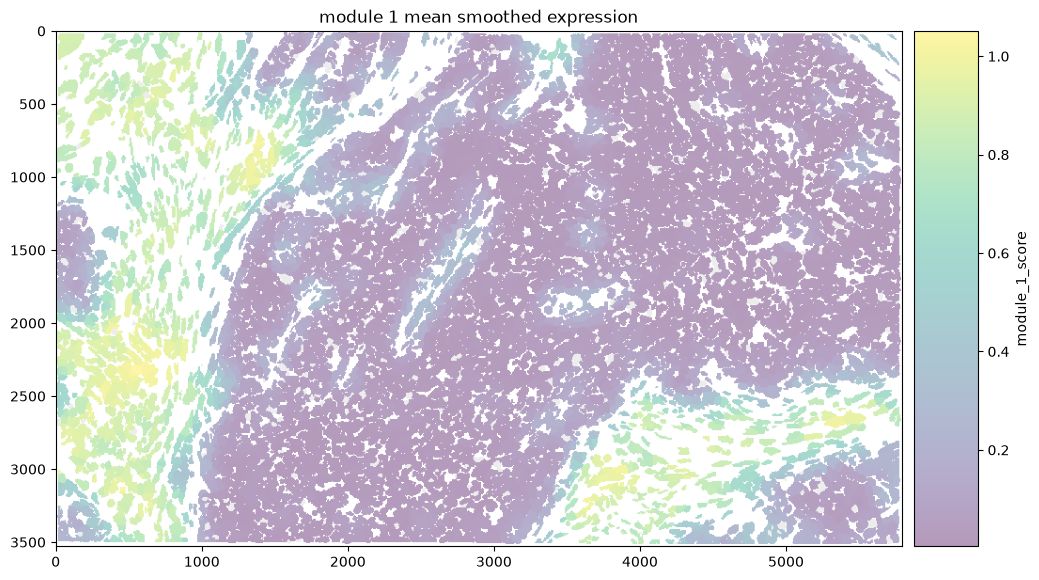

In [9]:
adata.obs["module_1_score"] = X_smooth[:, [i for i, m in enumerate(modules) if m == 1]].mean(axis=1)
sdata["table"].obs["module_1_score"] = pd.Series(
    adata.obs["module_1_score"].reindex(sdata["table"].obs_names).values, index=sdata["table"].obs_names
)
sdata.pl.render_labels("cell_labels", color="module_1_score", cmap="viridis").pl.show(
    coordinate_systems="global", title="module 1 mean smoothed expression", figsize=(9, 6)
)


Module 1 absorbs most of the immune and stromal genes together, which is itself the
confounder from section 3 showing up again, from a different angle: a "spatial pattern"
built from top global SVGs is largely rediscovering which parts of the tissue are which
cell-type compartment, not a pattern that exists independently of cell type.


## 7. Imputation is out of scope here

Predicting genes never measured in a panel (Tangram, gimVI, ENVI) is not covered hands-on
in this notebook. The one-line version for later: never run SVG detection on imputed genes
and report the hits. Imputation raises spatial autocorrelation by construction, because
the imputation model itself usually uses spatial or expression neighbours to fill in the
missing values. Denoising already-measured genes is a related but different problem, and
it's what ResolVI (the AI session later this course) is for; this notebook is strictly
about genes that were measured.


### Exercise

Repeat section 3 (condition on cell type) using `myeloid` instead of `epithelial_tumor` as
the restricting cell type. Does a similar fraction of the top-20 global SVGs survive? Is the
*same* set of genes surviving, or a different one?


In [10]:
# your answer here


## Pitfalls

- **"Spatially variable" is three different questions** (autocorrelation, domain DE,
  length scale) wearing one name. State which one your method answers.
- **The graph and the normalisation both move the ranking**, even though neither changes
  what the tissue actually looks like.
- **Cell-type composition is the single biggest confounder for SVG lists on this kind of
  panel.** Condition on cell type before claiming within-type spatial regulation.
- **A curated panel is not a discovery experiment.** 280 genes chosen partly *because* they
  are spatially interesting will inflate how impressive an SVG list looks.
- **Sepal needs a grid.** Do not run it directly on Xenium-style point coordinates.

## Further reading

- [Squidpy `spatial_autocorr` and `sepal` documentation](https://squidpy.readthedocs.io/en/stable/)
- Svensson (2020), *SpatialDE*; Sun et al. (2020), *SPARK*; Zhu et al. (2021), *SPARK-X*
- Andersson & Lundeberg (2021), *sepal*
- Systematic benchmarking of computational methods to identify spatially variable genes,
  Genome Biology (2025)
